In [51]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Ví dụ A.1

In [52]:
np.random.seed(12)
means = [[0, 3], [2, 0]]
cov1 = [[1, 0.3], [0.3, 1]]
cov2 = [[1, 0.2], [0.2, 1.5]]
N1 = 50
N2 = 40
N = N1 + N2
X1 = np.random.multivariate_normal(means[0], cov1, N1) # each row is a data point
X2 = np.random.multivariate_normal(means[1], cov2, N2)
# Combine classes and create labels
X = np.vstack((X1, X2))
y = np.hstack((np. ones(50), 2*np.ones(40)))

Number of samples in Class 1: 50
Number of samples in Class 2: 40
Mean of Class 1: [0.2041277  3.04666639]
Mean of Class 2: [ 1.80478915 -0.18249896]


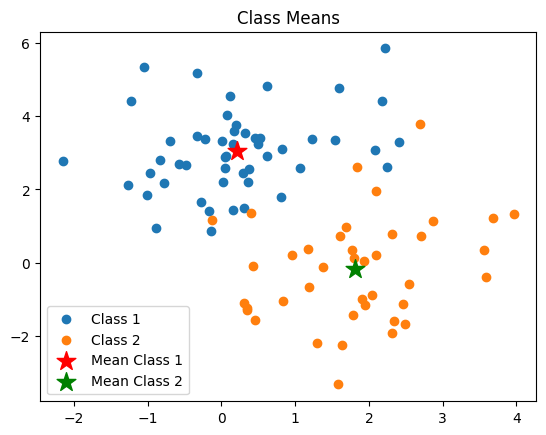

In [53]:
# Separate data by class to class1 (y=0) and class2 (y=1)
class1 = X[y == 1]
class2 = X[y == 2]
print("Number of samples in Class 1:", class1.shape[0])
print("Number of samples in Class 2:", class2.shape[0])
# Calculate class means
mean1 = np.mean(class1, axis=0)
mean2 = np.mean(class2, axis=0)
print("Mean of Class 1:", mean1)
print("Mean of Class 2:", mean2)
# Visualize class means
plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class 2')
plt.scatter(mean1[0], mean1[1], color='red', s=200, marker='*', label='Mean Class 1')
plt.scatter(mean2[0], mean2[1], color='green', s=200, marker='*', label='Mean Class 2')
plt.legend()
plt.title('Class Means')
plt.show()

In [54]:
# Build S_B
m1 = np.mean(X1.T, axis = 1, keepdims = True)
m2 = np.mean(X2.T, axis = 1, keepdims = True)
a = (m2 - m1)
S_B = a.dot(a.T)
# Build S_W
SW1 = X1.T - np.tile(m1, (1, N1))
SW2 = X2.T - np.tile(m2, (1, N2))
S_W = SW1.dot(SW1.T) + SW2.dot(SW2.T)
print('Between-class covariance matrix: S_B =\n', S_B)
print('Within-class covariance matrix: S_W =\n',S_W)

Between-class covariance matrix: S_B =
 [[ 2.56211707 -5.16880049]
 [-5.16880049 10.42750887]]
Within-class covariance matrix: S_W =
 [[ 86.83642101  27.51782236]
 [ 27.51782236 140.23997255]]


In [55]:
L, W = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
# use numpy's argmax and handle possible complex values by taking the real part
idx = np.argmax(np.real(L))
w = np.real(W[:, idx])
print(w)
print(w.shape)

[ 0.69467319 -0.71932549]
(2,)


(50,) (2,)
(2, 50) (2, 40)


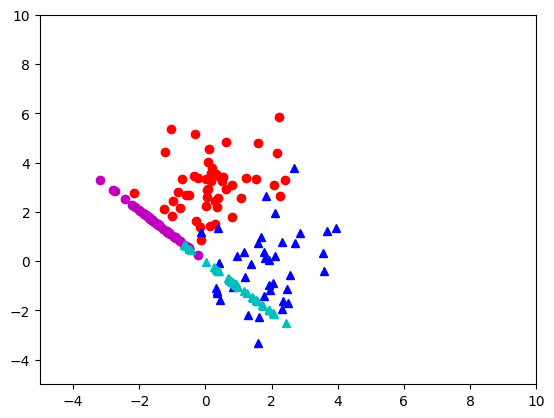

In [56]:
# Visualize data
plt.plot(X1[:, 0], X1[:, 1], 'ro')
plt.plot(X2[:, 0], X2[:, 1], 'b^')
plt.axis([-5, 10, -5, 10])
#Compute projections of data points on to LDA's dimention
#
norm_W = w.T.dot(w)
X1_tmp = X1.dot(w)/norm_W
X2_tmp = X2.dot(w)/norm_W
print(X1_tmp.shape, w.shape)
X1_p = np.multiply(w.reshape(2,1), X1_tmp.T)
X2_p = np.multiply(w.reshape(2,1), X2_tmp.T)
print(X1_p.shape,X2_p.shape)
#Draw projected points
plt.plot(X1_p[0, :], X1_p[1, :], 'mo')
plt.plot(X2_p[0, :], X2_p[1, :], 'c^')
plt.show()

# Ví dụ A.2. (Bài thực hành 1)

In [57]:
data_path = 'd:/Workspace/HUS/Machine Learning/6. LDA/pd_speech_features.csv'
df = pd.read_csv(data_path)
print('Dataset shape:', df.shape)
print('Columns sample:', df.columns[:10].tolist())

# Tách X (drop id, class) và y
if 'id' in df.columns:
    X = df.drop(columns=['id','class'])
else:
    X = df.drop(columns=['class'])
y = df['class'].values
print('X.shape, y.shape =', X.shape, y.shape)

# Chuẩn hoá
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('X_scaled shape:', X_scaled.shape)


Dataset shape: (756, 755)
Columns sample: ['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter']
X.shape, y.shape = (756, 753) (756,)
X_scaled shape: (756, 753)


## Giảm chiều: PCA (2D) và LDA (1D)

In [58]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('X_pca shape:', X_pca.shape)

# Ensure labels align with X_scaled: prefer df['class'] if lengths mismatch
if 'df' in globals() and hasattr(df, 'shape'):
	df_labels = df['class'].values
else:
	df_labels = None

if 'y' in globals() and len(y) == X_scaled.shape[0]:
	y_used = y
elif df_labels is not None and len(df_labels) == X_scaled.shape[0]:
	y_used = df_labels
else:
	# fallback: raise a clear error
	raise ValueError(f'Cannot find labels matching X_scaled (n_samples={X_scaled.shape[0]}). '
					 f'len(y)={len(y) if "y" in globals() else "N/A"}, '
					 f'len(df_labels)={len(df_labels) if df_labels is not None else "N/A"}')

print('Using labels of length', len(y_used))

# LDA 1D
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y_used)
print('X_lda shape:', X_lda.shape)

# DataFrames for plotting and convenience
df_pca = pd.DataFrame(X_pca, columns=['pca1','pca2'])
df_pca['class'] = y_used
df_lda = pd.DataFrame(X_lda, columns=['lda1'])
df_lda['class'] = y_used


X_pca shape: (756, 2)
Using labels of length 756
X_lda shape: (756, 1)


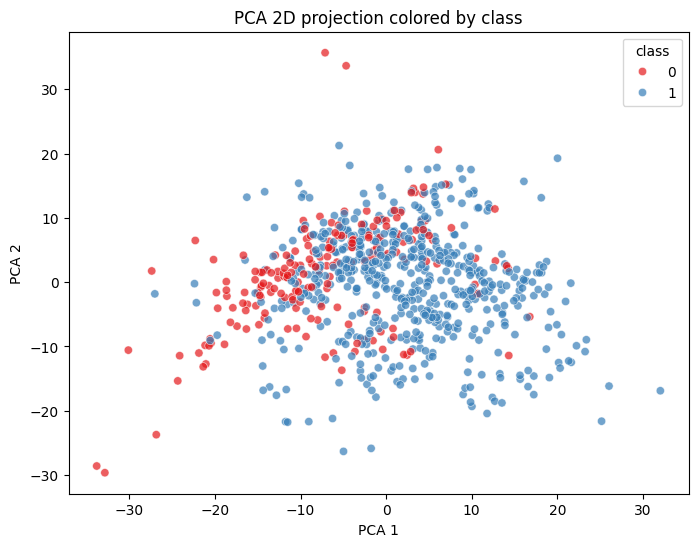

In [59]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca['pca1'], y=df_pca['pca2'], hue=df_pca['class'], palette='Set1', alpha=0.7)
plt.title('PCA 2D projection colored by class')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='class')
plt.show()

## 1: Dữ liệu đã giảm chiều — chia Train=500, Test=rest

Total samples: 756

Evaluating on LDA (1D)
--- LogisticRegression ---
Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00       191

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

Confusion matrix:
 [[ 65   0]
 [  0 191]]


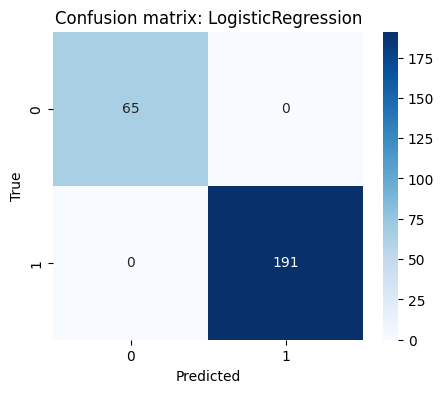

--- GaussianNB ---
Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00       191

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

Confusion matrix:
 [[ 65   0]
 [  0 191]]


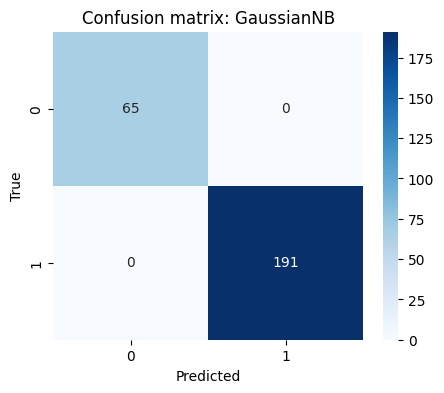


Evaluating on PCA (2D)
--- LogisticRegression ---
Accuracy: 0.796875
Classification report:
              precision    recall  f1-score   support

           0       0.71      0.34      0.46        65
           1       0.81      0.95      0.88       191

    accuracy                           0.80       256
   macro avg       0.76      0.65      0.67       256
weighted avg       0.78      0.80      0.77       256

Confusion matrix:
 [[ 22  43]
 [  9 182]]


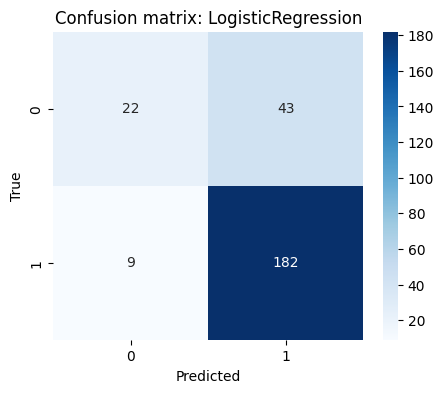

--- GaussianNB ---
Accuracy: 0.78125
Classification report:
              precision    recall  f1-score   support

           0       0.70      0.25      0.36        65
           1       0.79      0.96      0.87       191

    accuracy                           0.78       256
   macro avg       0.74      0.60      0.62       256
weighted avg       0.77      0.78      0.74       256

Confusion matrix:
 [[ 16  49]
 [  7 184]]


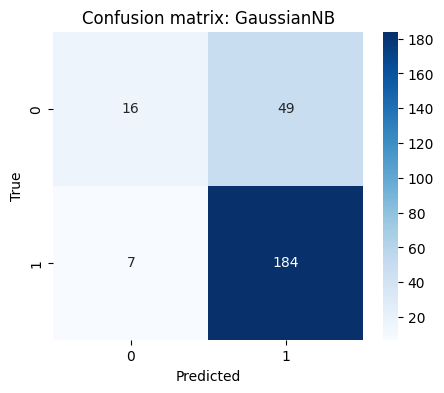


Summary of accuracies:
{'PCA': {'LogisticRegression': 0.796875, 'GaussianNB': 0.78125}, 'LDA': {'LogisticRegression': 1.0, 'GaussianNB': 1.0}}


In [60]:
# Prepare PCA and LDA feature matrices (these were computed earlier in the notebook)
X_pca_feats = df_pca[['pca1','pca2']].values
X_lda_feats = df_lda[['lda1']].values.reshape(-1,1)
y_all = y_used
n_samples = X_pca_feats.shape[0]
print('Total samples:', n_samples)
if n_samples < 2:
    raise ValueError('Not enough samples to split and train')

# We'll compute a single train/test index split so PCA and LDA results are comparable
idx = np.arange(n_samples)
if n_samples >= 500:
    # use exactly 500 training examples (stratified) and the rest for testing
    idx_train, idx_test = train_test_split(idx, train_size=500, stratify=y_all, random_state=42)
else:
    # fallback: 70/30 stratified split when dataset too small
    idx_train, idx_test = train_test_split(idx, test_size=0.3, stratify=y_all, random_state=42)
    print(f'Using 70/30 split because n_samples={n_samples}: train={len(idx_train)}, test={len(idx_test)}')

# Build train/test sets for both representations using same indices
Xp_train, Xp_test = X_pca_feats[idx_train], X_pca_feats[idx_test]
Xl_train, Xl_test = X_lda_feats[idx_train], X_lda_feats[idx_test]
yp_train, yp_test = y_all[idx_train], y_all[idx_test]
# Use the same labels for LDA (they are identical)
yl_train, yl_test = yp_train, yp_test

# Models to evaluate
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'GaussianNB': GaussianNB()
}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, plot_cm=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    cr = classification_report(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    print(f'--- {name} ---')
    print('Accuracy:', acc)
    print('Classification report:')
    print(cr)
    print('Confusion matrix:\n', cm)
    if plot_cm:
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.title(f'Confusion matrix: {name}')
        plt.show()
    return acc, cm

# Evaluate on LDA (1D) and PCA (2D) and store results
results = {'PCA': {}, 'LDA': {}}

print('\nEvaluating on LDA (1D)')
for n, m in models.items():
    acc, cm = evaluate(n, m, Xl_train, Xl_test, yl_train, yl_test)
    results['LDA'][n] = acc

print('\nEvaluating on PCA (2D)')
for n, m in models.items():
    acc, cm = evaluate(n, m, Xp_train, Xp_test, yp_train, yp_test)
    results['PCA'][n] = acc

print('\nSummary of accuracies:')
print(results)

Starting full-data experiments (train:test = 3:1)...
Using train=567, test=189 (3:1 stratified)

-- Full (original) data --
[LogisticRegression] Accuracy: 0.8360
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        48
           1       0.87      0.91      0.89       141

    accuracy                           0.84       189
   macro avg       0.79      0.76      0.77       189
weighted avg       0.83      0.84      0.83       189



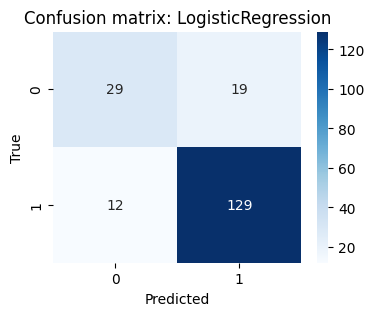

[GaussianNB] Accuracy: 0.7513
              precision    recall  f1-score   support

           0       0.51      0.60      0.55        48
           1       0.86      0.80      0.83       141

    accuracy                           0.75       189
   macro avg       0.68      0.70      0.69       189
weighted avg       0.77      0.75      0.76       189



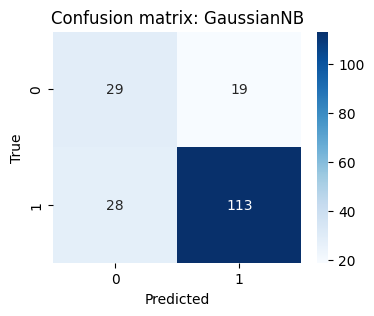


-- PCA (2D) reduced data --
[LogisticRegression] Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.69      0.38      0.49        48
           1       0.82      0.94      0.88       141

    accuracy                           0.80       189
   macro avg       0.75      0.66      0.68       189
weighted avg       0.78      0.80      0.78       189



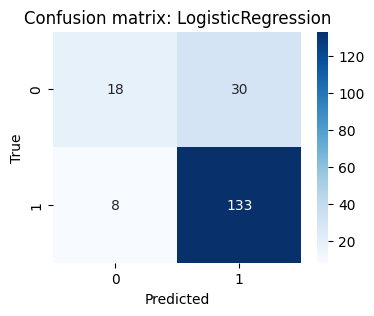

[GaussianNB] Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.69      0.38      0.49        48
           1       0.82      0.94      0.88       141

    accuracy                           0.80       189
   macro avg       0.75      0.66      0.68       189
weighted avg       0.78      0.80      0.78       189



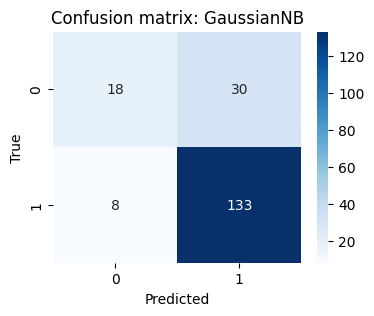


-- LDA (1D) reduced data --
[LogisticRegression] Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00       141

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189



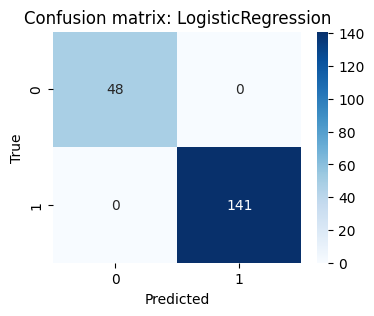

[GaussianNB] Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00       141

    accuracy                           1.00       189
   macro avg       1.00      1.00      1.00       189
weighted avg       1.00      1.00      1.00       189



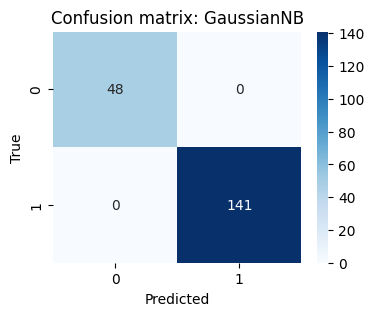


Summary of accuracies:
Full: {'LogisticRegression': 0.8359788359788359, 'GaussianNB': 0.7513227513227513}
PCA : {'LogisticRegression': 0.798941798941799, 'GaussianNB': 0.798941798941799}
LDA : {'LogisticRegression': 1.0, 'GaussianNB': 1.0}

Variability by model (max - min across representations): {'LogisticRegression': 0.20105820105820105, 'GaussianNB': 0.24867724867724872}
Model with larger accuracy change across data types: GaussianNB (change=0.2487)
Variability by data type (max - min across models): {'Full': 0.08465608465608465, 'PCA': 0.0, 'LDA': 0.0}
Data type with larger accuracy change across models: Full (change=0.0847)

Explanation:
 - A larger variability by model means that classifier is more sensitive to feature reduction (accuracy changes more when moving from full to reduced features).
 - A larger variability by data type means the choice of representation (full / PCA / LDA) affects model performance more strongly.
 - In practice, models with simpler assumptions (e.g., 

In [61]:
# 2: Full-data experiments (3:1 split) and compare with reduced-data results
from sklearn.model_selection import train_test_split
import numpy as np
print('Starting full-data experiments (train:test = 3:1)...')
# Prepare indices for a stratified 3:1 split
n = X_scaled.shape[0]
idx = np.arange(n)
train_idx, test_idx = train_test_split(idx, test_size=0.25, stratify=y_used, random_state=42)
print(f'Using train={len(train_idx)}, test={len(test_idx)} (3:1 stratified)')
# Full (original scaled) features
X_full_train, X_full_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y_used[train_idx], y_used[test_idx]
# Reduced representations (PCA 2D and LDA 1D) - ensure these DataFrames exist
X_pca_all = df_pca[['pca1','pca2']].values
X_lda_all = df_lda[['lda1']].values.reshape(-1,1)
X_pca_train, X_pca_test = X_pca_all[train_idx], X_pca_all[test_idx]
X_lda_train, X_lda_test = X_lda_all[train_idx], X_lda_all[test_idx]
# Models to evaluate
models = {'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42), 'GaussianNB': GaussianNB()}
results_full = {}
results_pca = {}
results_lda = {}
def eval_and_store(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)
    acc = accuracy_score(yte, ypred)
    print(f'[{name}] Accuracy: {acc:.4f}')
    print(classification_report(yte, ypred))
    cm = confusion_matrix(yte, ypred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return acc
# Evaluate on full data
print('\n-- Full (original) data --')
for n, m in models.items():
    results_full[n] = eval_and_store(n, m, X_full_train, X_full_test, y_train, y_test)
# Evaluate on PCA(2D)
print('\n-- PCA (2D) reduced data --')
for n, m in models.items():
    results_pca[n] = eval_and_store(n, m, X_pca_train, X_pca_test, y_train, y_test)
# Evaluate on LDA(1D)
print('\n-- LDA (1D) reduced data --')
for n, m in models.items():
    results_lda[n] = eval_and_store(n, m, X_lda_train, X_lda_test, y_train, y_test)
# Summaries
print('\nSummary of accuracies:')
print('Full:', results_full)
print('PCA :', results_pca)
print('LDA :', results_lda)
# Analyze variability by model (how much each model's accuracy changes across representations)
variability_model = {}
for n in models.keys():
    vals = [results_full.get(n, 0), results_pca.get(n, 0), results_lda.get(n, 0)]
    variability_model[n] = max(vals) - min(vals)
print('\nVariability by model (max - min across representations):', variability_model)
best_change_model = max(variability_model, key=variability_model.get)
print(f'Model with larger accuracy change across data types: {best_change_model} (change={variability_model[best_change_model]:.4f})')
# Analyze variability by data type (how much accuracy differs between models for the same representation)
variability_data = {}
for label, d in [('Full', results_full), ('PCA', results_pca), ('LDA', results_lda)]:
    vals = list(d.values())
    variability_data[label] = max(vals) - min(vals) if len(vals) > 0 else 0
print('Variability by data type (max - min across models):', variability_data)
best_change_data = max(variability_data, key=variability_data.get)
print(f'Data type with larger accuracy change across models: {best_change_data} (change={variability_data[best_change_data]:.4f})')
# Short explanation
print('\nExplanation:')
print(' - A larger variability by model means that classifier is more sensitive to feature reduction (accuracy changes more when moving from full to reduced features).')
print(' - A larger variability by data type means the choice of representation (full / PCA / LDA) affects model performance more strongly.')
print(' - In practice, models with simpler assumptions (e.g., Naive Bayes) can be more sensitive to feature correlations, while linear models (LogisticRegression) can be more robust depending on separability.')